In [ ]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

TypedDict: checked by type checker, not enforced by Python runtime happens at Compile time.

BaseModel: enforced when your code runs at the Run time

In [ ]:
class SimpleState(TypedDict):
    input_text: str
    output_text: str

In [ ]:
SimpleState(input_text="hello", output_text="HELLO")

{'input_text': 'hello', 'output_text': 'HELLO'}

In [ ]:
def node1(state : SimpleState) -> SimpleState:
    return SimpleState(input_text="hello", output_text=state["input_text"] + " node1 is done ")

In [ ]:
def node2(state : SimpleState) -> SimpleState:
    return SimpleState(input_text="hello", output_text=state["output_text"] + " node2 is done ")

In [ ]:
def node3(state : SimpleState) -> SimpleState:
    return SimpleState(input_text="hello", output_text=state["output_text"] +  "node3 is done ")

In [ ]:
def create_simple_graph():
    builder = StateGraph(SimpleState)

    # add the nodes
    builder.add_node("node1", node1)
    builder.add_node("node2", node2)
    builder.add_node("node3", node3)

    # connect the edges
    builder.add_edge(START, "node1")
    builder.add_edge("node1", "node2")
    builder.add_edge("node2", "node3")
    builder.add_edge("node3", END)

    # make it langchain runnable
    graph = builder.compile()

    return graph

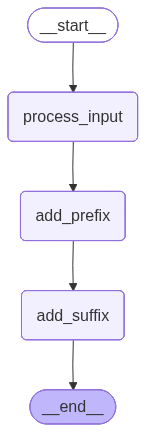

In [ ]:
graph = create_simple_graph()
graph

In [ ]:
initial_state= {'input_text': "hello"}

graph.invoke(initial_state)

{'input_text': 'hello',
 'output_text': 'hello node1 is done  node2 is done node3 is done '}